# Novelty Metric for Yes-And Games

This notebook demonstrates how to compute and analyze **novelty** in collaborative storytelling, specifically for "Yes-And" improvisation games where participants build stories together by accepting and building upon each other's contributions.

## What is the Novelty Metric?

**Novelty** measures the semantic variability between consecutive contributions in a story. In Yes-And games, participants must balance:
- **Maintaining narrative coherence** (building on what came before)
- **Introducing new ideas** (keeping the story interesting and creative)

We quantify this balance by computing the **cosine distance** between sentence embeddings of consecutive contributions. Higher distances indicate stronger semantic shifts, suggesting more novel narrative directions.

## Research Context

This metric helps us compare creativity patterns across different collaboration conditions:
- **HH (Human-Human)**: Two humans collaborating
- **AIH (AI-Human)**: Human collaborating with an AI agent

By analyzing novelty separately for each speaker type, we can understand how AI collaboration affects human creativity and how AI agents contribute to the creative process.

---


## Setup and Dependencies


In [1]:
# Install required packages (uncomment if needed)
# !pip install sentence-transformers scikit-learn numpy pandas matplotlib seaborn

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Dependencies loaded successfully.")


/Users/idan.vidra/workspace/Personal/Yes-And-Game-Paper/ya_game_paper_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies loaded successfully.


## Data Loading and Exploration

Let's start by understanding our dataset structure.


In [2]:
def load_stories_from_json(file_path):
    """
    Load stories from JSON file.
    
    Args:
        file_path: Path to JSON file containing stories
        
    Returns:
        stories: List of story dictionaries with 'id', 'messages', etc.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def extract_sentences_from_story(story):
    """
    Extract sentences from a story dictionary.
    
    Args:
        story: Dictionary with 'messages' key containing list of message dicts
        
    Returns:
        sentences: List of sentence strings
    """
    sentences = []
    for message in story['messages']:
        content = message['content'].strip()
        if content and content != "________________":  # Skip empty or separator messages
            sentences.append(content)
    return sentences

# Load the datasets
hh_stories = load_stories_from_json("../Story Datasets/hh_stories.json")
aih_stories = load_stories_from_json("../Story Datasets/aih_stories.json")

print(f"Loaded {len(hh_stories)} Human-Human stories")
print(f"Loaded {len(aih_stories)} AI-Human stories")


Loaded 131 Human-Human stories
Loaded 75 AI-Human stories


### Let's Look at Example Stories

Understanding the data structure is crucial for interpreting our novelty measurements.


In [3]:
# Show example HH story
if hh_stories:
    hh_example = hh_stories[0]
    print("HUMAN-HUMAN STORY EXAMPLE:")
    print(f"Story ID: {hh_example['id']}")
    print(f"Number of messages: {len(hh_example['messages'])}")
    print("\nConversation:")
    
    for i, message in enumerate(hh_example['messages'][:6]):  # Show first 6 exchanges
        role = message['role']
        content = message['content']
        speaker = "Human 1" if role == "human1" else "Human 2"
        print(f"  {i+1}. {speaker}: {content}")
    
    if len(hh_example['messages']) > 6:
        print(f"  ... ({len(hh_example['messages']) - 6} more messages)")

print("\n" + "="*60 + "\n")

# Show example AIH story
if aih_stories:
    aih_example = aih_stories[0]
    print("AI-HUMAN STORY EXAMPLE:")
    print(f"Story ID: {aih_example['id']}")
    print(f"Number of messages: {len(aih_example['messages'])}")
    print("\nConversation:")
    
    for i, message in enumerate(aih_example['messages'][:6]):  # Show first 6 exchanges
        role = message['role']
        content = message['content']
        speaker = "Human" if role == "human" else "AI"
        print(f"  {i+1}. {speaker}: {content}")
    
    if len(aih_example['messages']) > 6:
        print(f"  ... ({len(aih_example['messages']) - 6} more messages)")


HUMAN-HUMAN STORY EXAMPLE:
Story ID: HH_1
Number of messages: 20

Conversation:
  1. Human 1: Remember three weeks ago when we saw a movie?
  2. Human 2: yes with the cool 3D glasses
  3. Human 1: yes and it looked so real that you fell off your chair
  4. Human 2: yes and I broke my neck in 4 places
  5. Human 1: yes and the doctors built you back as a robot - stronger than ever before
  6. Human 2: yes! and they made my arms from dragon metal
  ... (14 more messages)


AI-HUMAN STORY EXAMPLE:
Story ID: AIH_2
Number of messages: 8

Conversation:
  1. Human: You were selected to join Elon Musk's first Mars mission
  2. AI: Yes! and upon arriving at the Starbase, you meet the rest of the crew members who have been carefully chosen for their diverse skill sets and backgrounds.
  3. Human: Yes! and it's an awesome group of people from all over the world, but they have one big question
  4. AI: : Yes! and that big question is whether they'll be able to create a self-sustaining community on

---

## Core Novelty Computation Functions

Now let's implement the heart of our novelty metric: computing semantic distances between consecutive sentences.


### The Core Algorithm

The novelty computation works in three steps:

1. **Embed sentences** using a pre-trained transformer model
2. **Pair consecutive sentences** (S1→S2, S2→S3, S3→S4, ...)
3. **Compute cosine distances** between each pair

Higher distances indicate greater semantic novelty between consecutive contributions.


In [4]:
def compute_consecutive_distances(sentences, model):
    """
    Compute consecutive sentence distances for a list of sentences.
    Higher distances indicate greater semantic novelty between successive sentences.
    
    Args:
        sentences: List of sentences
        model: SentenceTransformer model
        
    Returns:
        numpy array of distances between consecutive sentences
    """
    if len(sentences) < 2:
        return np.array([])

    # Step 1: Create embeddings for all sentences
    embeddings = model.encode(sentences)
    
    # Step 2: Create pairs of consecutive sentences
    # embeddings[:-1] = [S1, S2, S3] (all except last)
    # embeddings[1:]  = [S2, S3, S4] (all except first)
    
    # Step 3: Compute cosine distances between consecutive pairs
    # The diagonal gives us: distance(S1,S2), distance(S2,S3), distance(S3,S4), ...
    distances = cosine_distances(embeddings[:-1], embeddings[1:]).diagonal()
    
    return distances

# Let's test this with a simple example
print("Testing consecutive distance computation\n")

# Load a small, fast model for demonstration
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Loaded embedding model: all-MiniLM-L6-v2")

# Test with a simple example
test_sentences = [
    "The cat sat on the mat.",
    "The feline rested on the rug.",  # Similar meaning, should have low distance
    "Suddenly, a spaceship landed nearby.",  # Very different, should have high distance
    "The aliens emerged from their craft."  # Related to previous, moderate distance
]

test_distances = compute_consecutive_distances(test_sentences, model)

print("\nTest sentences:")
for i, sentence in enumerate(test_sentences):
    print(f"  {i+1}. {sentence}")

print("\nConsecutive distances:")
for i, distance in enumerate(test_distances):
    print(f"  S{i+1} → S{i+2}: {distance:.4f}")

print("\nNotice how the distance is highest between sentences 2→3 (cat to spaceship)!")


Testing consecutive distance computation

Loaded embedding model: all-MiniLM-L6-v2

Test sentences:
  1. The cat sat on the mat.
  2. The feline rested on the rug.
  3. Suddenly, a spaceship landed nearby.
  4. The aliens emerged from their craft.

Consecutive distances:
  S1 → S2: 0.4510
  S2 → S3: 0.7788
  S3 → S4: 0.5837

Notice how the distance is highest between sentences 2→3 (cat to spaceship)!


### Speaker Label Assignment

For our analysis, we need to separate novelty measurements by speaker type to compare human vs AI creativity patterns.


In [5]:
def get_speaker_labels_for_story(story):
    """
    Generate speaker labels for a specific story based on its messages.
    
    Args:
        story: Story dictionary with 'messages' key
        
    Returns:
        List of speaker labels for each sentence
    """
    labels = []
    for message in story['messages']:
        content = message['content'].strip()
        if content and content != "________________":
            role = message['role']
            if role in ['human', 'human1', 'human2']:
                # Distinguish between HH and AIH human contributions
                label = 'H_AIH' if role == 'human' else 'H_HH'
                labels.append(label)
            elif role == 'ai':
                labels.append('AI_AIH')
    return labels

# Test speaker labeling
print("Testing speaker labeling\n")

if hh_stories:
    hh_labels = get_speaker_labels_for_story(hh_stories[0])
    print(f"HH story labels (first 10): {hh_labels[:10]}")

if aih_stories:
    aih_labels = get_speaker_labels_for_story(aih_stories[0])
    print(f"AIH story labels (first 10): {aih_labels[:10]}")

print("\nLabel meanings:")
print("  • H_HH: Human in Human-Human collaboration")
print("  • H_AIH: Human in AI-Human collaboration")
print("  • AI_AIH: AI in AI-Human collaboration")


Testing speaker labeling

HH story labels (first 10): ['H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH', 'H_HH']
AIH story labels (first 10): ['H_AIH', 'AI_AIH', 'H_AIH', 'AI_AIH', 'H_AIH', 'AI_AIH', 'H_AIH', 'AI_AIH']

Label meanings:
  • H_HH: Human in Human-Human collaboration
  • H_AIH: Human in AI-Human collaboration
  • AI_AIH: AI in AI-Human collaboration


### Complete Analysis Function

Now let's put it all together to analyze novelty across our entire dataset, separating results by speaker type.


In [6]:
def analyze_consecutive_novelty(hh_stories, aih_stories, model_name='all-MiniLM-L6-v2', sentence_filter=2):
    """
    Analyze consecutive sentence novelty within each story.
    For each story, compute distances between consecutive sentences and label by speaker.
    
    Args:
        hh_stories: List of HH story dictionaries
        aih_stories: List of AIH story dictionaries
        model_name: SentenceTransformer model name
        sentence_filter: Minimum number of sentences required
        
    Returns:
        dict: Results for H_HH, H_AIH, and AI_AIH groups
    """
    print(f"🔄 Loading model: {model_name}...")
    model = SentenceTransformer(model_name)
    
    # Initialize results for each speaker type
    h_hh_distances = []    # Human contributions in HH stories
    h_aih_distances = []   # Human contributions in AIH stories
    ai_aih_distances = []  # AI contributions in AIH stories
    
    print(f"📊 Processing {len(hh_stories)} HH stories...")
    # Process HH stories (all sentences are human)
    for story in hh_stories:
        sentences = extract_sentences_from_story(story)
        if len(sentences) > sentence_filter:
            # All sentences in HH are human contributions
            story_distances = compute_consecutive_distances(sentences, model)
            h_hh_distances.extend(story_distances)
    
    print(f"🤖 Processing {len(aih_stories)} AIH stories...")
    # Process AIH stories (alternating human/AI)
    for story in aih_stories:
        sentences = extract_sentences_from_story(story)
        if len(sentences) > sentence_filter:
            # Get speaker labels for this story
            speaker_labels = get_speaker_labels_for_story(story)
            
            # Compute distances between consecutive sentences
            story_distances = compute_consecutive_distances(sentences, model)
            
            # Assign distances to appropriate speaker groups
            # Note: we assign based on the SECOND sentence in each pair (the responder)
            for i, distance in enumerate(story_distances):
                responding_speaker = speaker_labels[i + 1]  # Label of the second sentence in the pair
                if responding_speaker == 'H_AIH':
                    h_aih_distances.append(distance)
                elif responding_speaker == 'AI_AIH':
                    ai_aih_distances.append(distance)
    
    results = {
        'H_HH': np.array(h_hh_distances),
        'H_AIH': np.array(h_aih_distances),
        'AI_AIH': np.array(ai_aih_distances)
    }
    
    print(f"✅ Analysis complete!")
    return results, model_name

def get_novelty_statistics(results):
    """
    Compute statistics for novelty results.
    """
    stats = {}
    
    for group, values in results.items():
        if len(values) > 0:
            stats[group] = {
                'count': len(values),
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values)
            }
        else:
            stats[group] = {
                'count': 0,
                'mean': np.nan,
                'std': np.nan,
                'median': np.nan,
                'min': np.nan,
                'max': np.nan
            }
    
    return stats


In [7]:
from collections import Counter

story = aih_stories[0]
# What extract/labels give
sents = extract_sentences_from_story(story)
labs  = get_speaker_labels_for_story(story)
print(len(sents), len(labs), Counter(labs)[:])
print(list(zip(labs[:6], sents[:6])))

8 8 0
[('H_AIH', "You were selected to join Elon Musk's first Mars mission"), ('AI_AIH', 'Yes! and upon arriving at the Starbase, you meet the rest of the crew members who have been carefully chosen for their diverse skill sets and backgrounds.'), ('H_AIH', "Yes! and it's an awesome group of people from all over the world, but they have one big question"), ('AI_AIH', ": Yes! and that big question is whether they'll be able to create a self-sustaining community on Mars that could eventually support the growth of human civilization."), ('H_AIH', 'Yes! We get started by assigning roles and responsibilities on the first priority - setting up the starbase'), ('AI_AIH', 'Yes! and everyone is excited as they begin working on their respective tasks, such as assembling the habitat modules, setting up life-support systems, and initiating the first stages of resource extraction and agriculture on Mars.')]


In [8]:
from collections import Counter

story = aih_stories[0]
# What extract/labels give
sents = extract_sentences_from_story(story)
labs  = get_speaker_labels_for_story(story)
print(len(sents), len(labs), Counter(labs)[:])
print(list(zip(labs[:6], sents[:6])))

8 8 0
[('H_AIH', "You were selected to join Elon Musk's first Mars mission"), ('AI_AIH', 'Yes! and upon arriving at the Starbase, you meet the rest of the crew members who have been carefully chosen for their diverse skill sets and backgrounds.'), ('H_AIH', "Yes! and it's an awesome group of people from all over the world, but they have one big question"), ('AI_AIH', ": Yes! and that big question is whether they'll be able to create a self-sustaining community on Mars that could eventually support the growth of human civilization."), ('H_AIH', 'Yes! We get started by assigning roles and responsibilities on the first priority - setting up the starbase'), ('AI_AIH', 'Yes! and everyone is excited as they begin working on their respective tasks, such as assembling the habitat modules, setting up life-support systems, and initiating the first stages of resource extraction and agriculture on Mars.')]


### Complete Analysis Function

Now let's put it all together to analyze novelty across our entire dataset, separating results by speaker type.


## Running the Complete Analysis

Now let's execute our novelty analysis on the full dataset and visualize the results!


In [9]:
# Run the complete analysis
print("Running complete novelty analysis\n")

# Use the fast model for demonstration (you can change this to 'all-roberta-large-v1')
model_name = 'all-MiniLM-L6-v2'

# Execute the analysis
results, used_model = analyze_consecutive_novelty(
    hh_stories, aih_stories, 
    model_name=model_name, 
    sentence_filter=2
)

# Compute statistics
stats = get_novelty_statistics(results)

print(f"\nNovelty analysis results (Model: {used_model})\n")
print("=" * 60)

for group, group_stats in stats.items():
    print(f"\n{group} (n={group_stats['count']}):") 
    if group_stats['count'] > 0:
        print(f"  Mean novelty: {group_stats['mean']:.4f}")
        print(f"  Std deviation: {group_stats['std']:.4f}")
        print(f"  Median: {group_stats['median']:.4f}")
        print(f"  Range: {group_stats['min']:.4f} - {group_stats['max']:.4f}")
    else:
        print("  No data available")


Running complete novelty analysis

🔄 Loading model: all-MiniLM-L6-v2...
📊 Processing 131 HH stories...
🤖 Processing 75 AIH stories...
✅ Analysis complete!

Novelty analysis results (Model: all-MiniLM-L6-v2)


H_HH (n=1551):
  Mean novelty: 0.5934
  Std deviation: 0.1598
  Median: 0.5931
  Range: 0.0000 - 1.0170

H_AIH (n=413):
  Mean novelty: 0.6133
  Std deviation: 0.1604
  Median: 0.6221
  Range: 0.1689 - 0.9422

AI_AIH (n=489):
  Mean novelty: 0.5638
  Std deviation: 0.1571
  Median: 0.5593
  Range: 0.0000 - 0.9724


## Visualization and Statistical Analysis


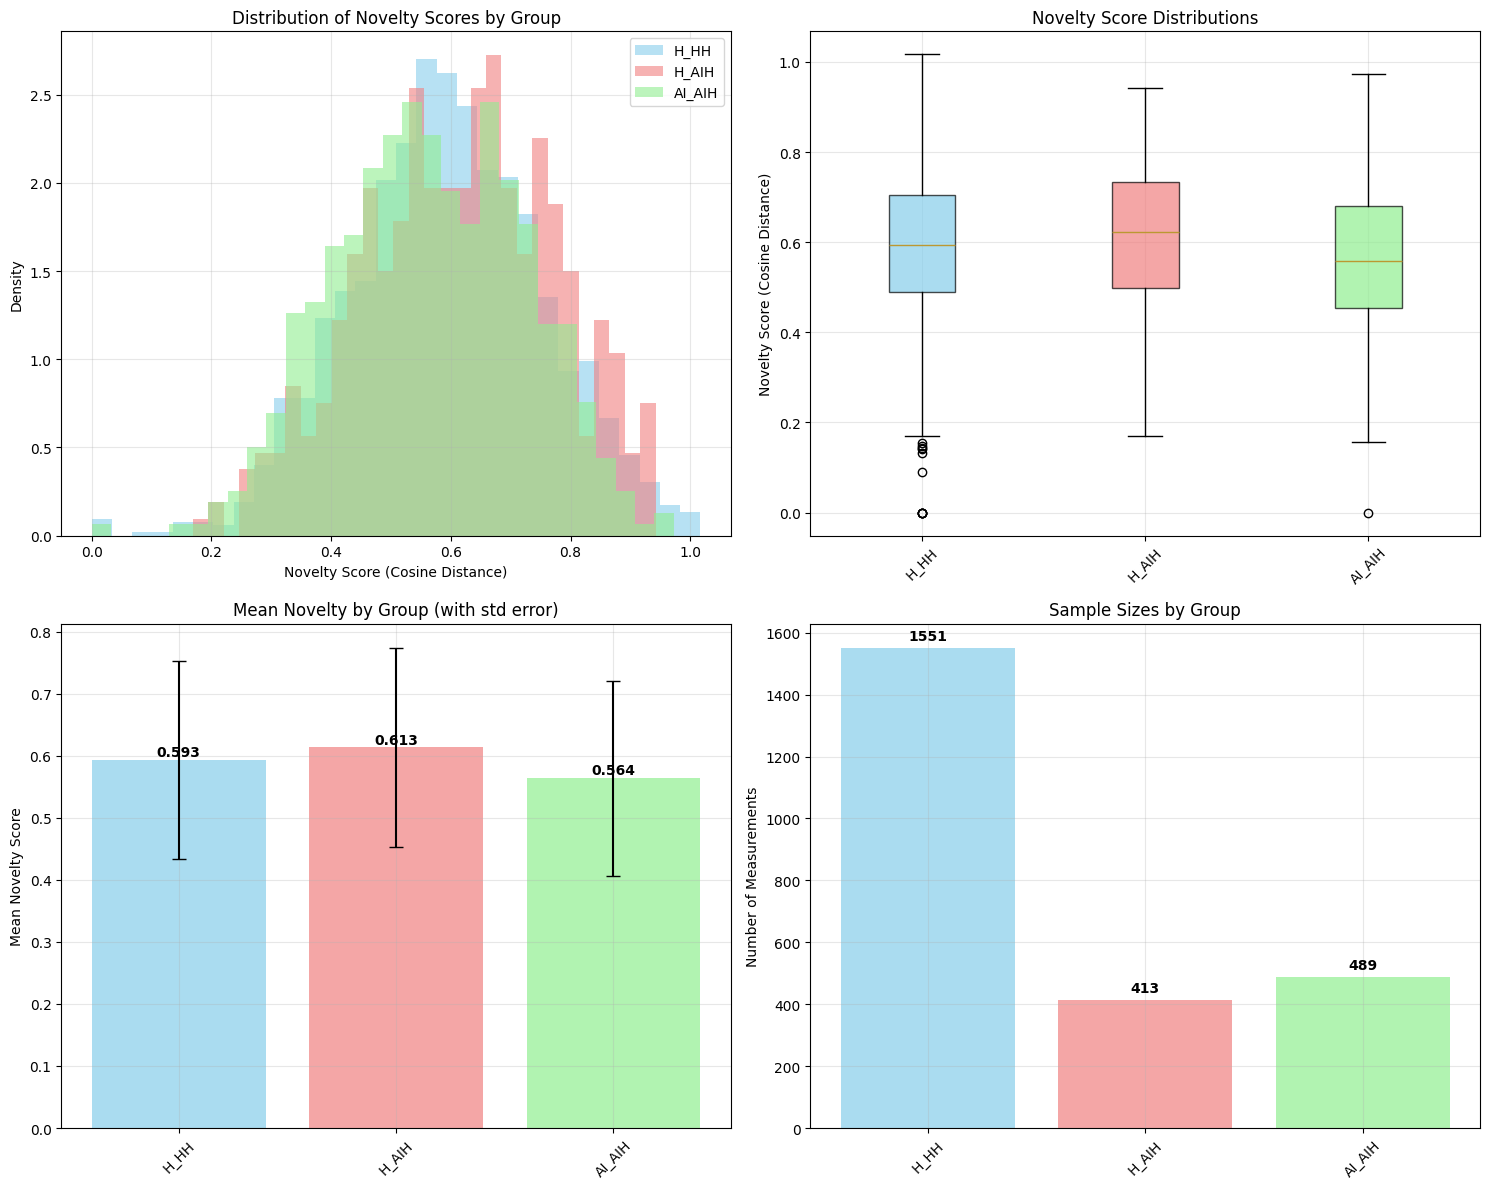

In [10]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Filter out groups with no data
groups_to_plot = [group for group, values in results.items() if len(values) > 0]
data_to_plot = [results[group] for group in groups_to_plot]
colors = ['skyblue', 'lightcoral', 'lightgreen'][:len(groups_to_plot)]

# 1. Distribution comparison (overlapping histograms)
ax1 = axes[0, 0]
for i, (group, data) in enumerate(zip(groups_to_plot, data_to_plot)):
    ax1.hist(data, bins=30, alpha=0.6, label=group, color=colors[i], density=True)
ax1.set_xlabel('Novelty Score (Cosine Distance)')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of Novelty Scores by Group')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plot comparison
ax2 = axes[0, 1]
box_plot = ax2.boxplot(data_to_plot, labels=groups_to_plot, patch_artist=True)
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Novelty Score (Cosine Distance)')
ax2.set_title('Novelty Score Distributions')
ax2.grid(True, alpha=0.3)
plt.setp(ax2.get_xticklabels(), rotation=45)

# 3. Mean comparison bar chart
ax3 = axes[1, 0]
means = [stats[group]['mean'] for group in groups_to_plot if not np.isnan(stats[group]['mean'])]
stds = [stats[group]['std'] for group in groups_to_plot if not np.isnan(stats[group]['std'])]
bars = ax3.bar(groups_to_plot, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax3.set_ylabel('Mean Novelty Score')
ax3.set_title('Mean Novelty by Group (with std error)')
ax3.grid(True, alpha=0.3)
plt.setp(ax3.get_xticklabels(), rotation=45)

# Add value labels on bars
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Sample size comparison
ax4 = axes[1, 1]
counts = [stats[group]['count'] for group in groups_to_plot]
bars = ax4.bar(groups_to_plot, counts, color=colors, alpha=0.7)
ax4.set_ylabel('Number of Measurements')
ax4.set_title('Sample Sizes by Group')
ax4.grid(True, alpha=0.3)
plt.setp(ax4.get_xticklabels(), rotation=45)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
             f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [11]:
# Statistical comparison between groups
print("\nStatistical insights\n")
print("=" * 50)

if len(groups_to_plot) >= 2:
    from scipy import stats as scipy_stats
    
    # Compare groups pairwise
    for i in range(len(groups_to_plot)):
        for j in range(i+1, len(groups_to_plot)):
            group1, group2 = groups_to_plot[i], groups_to_plot[j]
            data1, data2 = results[group1], results[group2]
            
            if len(data1) > 0 and len(data2) > 0:
                # Perform t-test
                t_stat, p_value = scipy_stats.ttest_ind(data1, data2)
                
                print(f"\n{group1} vs {group2}:")
                print(f"  Mean difference: {np.mean(data1) - np.mean(data2):.4f}")
                print(f"  T-statistic: {t_stat:.4f}")
                print(f"  P-value: {p_value:.4f}")
                
                if p_value < 0.001:
                    print("  Highly significant difference (p < 0.001)")
                elif p_value < 0.01:
                    print("  Very significant difference (p < 0.01)")
                elif p_value < 0.05:
                    print("  Significant difference (p < 0.05)")
                else:
                    print("  No significant difference (p >= 0.05)")

print(f"\n\nModel used: {used_model}")
print(f"Minimum story length: {2 + 1} sentences")
print(f"Total measurements: {sum(len(values) for values in results.values())}")



Statistical insights


H_HH vs H_AIH:
  Mean difference: -0.0200
  T-statistic: -2.2552
  P-value: 0.0242
  Significant difference (p < 0.05)

H_HH vs AI_AIH:
  Mean difference: 0.0295
  T-statistic: 3.5749
  P-value: 0.0004
  Highly significant difference (p < 0.001)

H_AIH vs AI_AIH:
  Mean difference: 0.0495
  T-statistic: 4.6647
  P-value: 0.0000
  Highly significant difference (p < 0.001)


Model used: all-MiniLM-L6-v2
Minimum story length: 3 sentences
Total measurements: 2453


## Interpreting the Results

### What Do These Numbers Mean?

**Novelty scores** range from 0 to 2 (cosine distance):
- **0.0**: Identical sentences (no novelty)
- **0.5-0.8**: Moderate semantic shift (typical for coherent storytelling)
- **1.0+**: High semantic shift (major topic/direction changes)
- **2.0**: Completely opposite meanings (rare in coherent stories)

### Research Questions to Explore:

1. **Do humans show different novelty patterns when collaborating with AI vs other humans?**
   - Compare H_HH vs H_AIH mean scores

2. **How does AI novelty compare to human novelty?**
   - Compare AI_AIH vs H_AIH and H_HH scores

3. **Are there differences in novelty variance between conditions?**
   - Look at standard deviations - higher variance might indicate more creative risk-taking

### Potential Findings:

- **Higher AI novelty** might suggest AI introduces more unexpected elements
- **Lower human novelty with AI** might indicate humans become more conservative
- **Similar patterns** might suggest successful collaboration adaptation

### Next Steps:

1. **Try different embedding models** to validate findings
2. **Analyze specific story examples** with high/low novelty
3. **Correlate with human ratings** of creativity and engagement
4. **Examine temporal patterns** within stories


---

## Summary and Usage

This notebook provides a complete implementation of the **Novelty metric** for analyzing creativity in collaborative storytelling.

### Key Functions:

- `compute_consecutive_distances()`: Core novelty computation
- `analyze_consecutive_novelty()`: Full dataset analysis with speaker separation
- `get_novelty_statistics()`: Statistical summary generation

### To Use This Code:

1. **Load your story data** in the expected JSON format
2. **Choose an embedding model** (we recommend starting with `all-MiniLM-L6-v2` for speed)
3. **Run the analysis** with your preferred parameters
4. **Interpret results** using the guidelines above

### Citation:

If you use this novelty metric in your research, please cite:

*@inproceedings{vidra2025playing,
  title        = {Playing Along: Building AI Agents for Co-Creation of Improvised Stories},
  author       = {Vidra, Idan Dov and Kimron, Gal and Noy, Lior and Shamir, Ariel},
  booktitle    = {Proceedings of the 16th International Conference on Computational Creativity (ICCC'25)},
  year         = {2025},
  address      = {Campinas, Brazil},
  url          = {https://computationalcreativity.net/iccc25/wp-content/uploads/papers/iccc25-vidra2025playing.pdf}
}*

---

**Happy analyzing! 🚀**
